# **CS3244 Group Project - SVM model**

## Introduction
Human Activity Recognition (HAR) is an important task in ubiquitous computing, involving the automatic classification of physical activities using sensor data. In this project, I focus on the classification of 12 human activities based on time-series signals collected from a smartphone's accelerometer and gyroscope. I implemented and evaluated various forms of Support Vector Machine (SVM)$^{[1]}$ models on the preprocessed dataset, explored different kernel functions, addressed class imbalance, and performed hyperparameter tuning to optimize model performance.

## Load Dataset

The dataset is derived from smartphone-based sensor readings, where subjects wore a device on their waist while performing activities. It includes both time and frequency domain features extracted from accelerometer and gyroscope signals. Each sample is a fixed-size window of sensor data, and each window is labeled with one of the 12 activity classes:

1. WALKING
2. WALKING_UPSTAIRS
3. WALKING_DOWNSTAIRS
4. SITTING
5. STANDING
6. LAYING
7. STAND_TO_SIT
8. SIT_TO_STAND
9. SIT_TO_LIE
10. LIE_TO_SIT
11. STAND_TO_LIE
12. LIE_TO_STAND

The dataset is split into a training set and a test set, with associated subject IDs and labels.

In [15]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# load the dataset
def load_data():
    X_train = np.loadtxt("/kaggle/input/3244project/Train/X_train.txt")
    y_train = np.loadtxt("/kaggle/input/3244project/Train/y_train.txt").astype(int)
    X_test = np.loadtxt("/kaggle/input/3244project/Test/X_test.txt")
    y_test = np.loadtxt("/kaggle/input/3244project/Test/y_test.txt").astype(int)
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_data()

## Data Pre-processing

- **PCA**: To reduce the dimensionality and possibly improve computational efficiency, I applied PCA to the training and test data, reducing the features to 300 components. The goal was to retain most of the variance while simplifying the feature space.
- **SMOTE**: To address class imbalance, especially in minority transition activities (classes 7 to 12), I used the SMOTE algorithm to synthetically oversample underrepresented classes to specific target values. This was done before model training in one of the experiment tracks.

In [16]:

from sklearn.decomposition import PCA

def apply_pca(X_train, X_test, n_components=300):
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    return X_train_pca, X_test_pca

X_train_pca, X_test_pca = apply_pca(X_train, X_test, n_components=300)


from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy={7: 100, 8: 100, 9: 300, 10: 100, 11: 100, 12: 300}, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_pca, y_train)


## Testing Different Types of SVM

### Linear SVM: 
Trained using LinearSVC, this model is computationally efficient and interpretable. However, its limitation to linear decision boundaries means it failed to capture the nonlinear relationships present in HAR data. Its accuracy was lower compared to other kernel-based SVMs.

In [33]:
# Linear SVM

from sklearn.svm import LinearSVC
svm = LinearSVC(C=10, max_iter=50000)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9443390259329538
Classification Report:
               precision    recall  f1-score   support

           1       0.95      1.00      0.97       496
           2       0.98      0.95      0.96       471
           3       1.00      0.99      0.99       420
           4       0.96      0.87      0.91       508
           5       0.90      0.97      0.94       556
           6       0.98      1.00      0.99       545
           7       0.72      0.57      0.63        23
           8       0.83      1.00      0.91        10
           9       0.58      0.59      0.58        32
          10       0.68      0.68      0.68        25
          11       0.67      0.61      0.64        49
          12       0.67      0.59      0.63        27

    accuracy                           0.94      3162
   macro avg       0.83      0.82      0.82      3162
weighted avg       0.94      0.94      0.94      3162

Confusion Matrix:
 [[494   2   0   0   0   0   0   0   0   0   0   0]
 [ 21 447 

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Polynomial SVM (degree=2): 
This model introduced nonlinear transformations using polynomial kernels. It achieved the highest overall accuracy (~95.5%) on the test set. However, the performance on minority classes was less consistent, with reduced recall for transitions like LIE_TO_STAND and STAND_TO_LIE.

In [45]:
# Polynomial SVM

svm = SVC(kernel='poly', degree=2, C=10, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9550917141049968
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.98       496
           2       0.97      0.96      0.96       471
           3       0.99      0.97      0.98       420
           4       0.97      0.89      0.93       508
           5       0.91      0.98      0.94       556
           6       1.00      1.00      1.00       545
           7       0.95      0.83      0.88        23
           8       1.00      1.00      1.00        10
           9       0.70      0.81      0.75        32
          10       0.76      0.76      0.76        25
          11       0.78      0.71      0.74        49
          12       0.75      0.67      0.71        27

    accuracy                           0.96      3162
   macro avg       0.89      0.88      0.89      3162
weighted avg       0.96      0.96      0.95      3162

Confusion Matrix:
 [[492   2   2   0   0   0   0   0   0   0   0   0]
 [ 17 452 

### RBF(Radial Basis Function) SVM: 
The RBF kernel maps data into an infinite-dimensional space, allowing for highly flexible decision boundaries. This model achieved high accuracy (~95.2%) and showed the best balance between performance on majority and minority classes. It consistently outperformed other variants in terms of robustness and generalization

In [19]:
# RBF SVM

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9516129032258065
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.97       496
           2       0.95      0.96      0.96       471
           3       0.99      0.95      0.97       420
           4       0.97      0.90      0.93       508
           5       0.92      0.98      0.95       556
           6       1.00      1.00      1.00       545
           7       0.95      0.78      0.86        23
           8       0.91      1.00      0.95        10
           9       0.65      0.75      0.70        32
          10       0.77      0.80      0.78        25
          11       0.74      0.69      0.72        49
          12       0.78      0.67      0.72        27

    accuracy                           0.95      3162
   macro avg       0.88      0.87      0.87      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[489   5   2   0   0   0   0   0   0   0   0   0]
 [ 16 454 

### Class-weighted SVM: 
By adjusting the penalty for misclassifying underrepresented classes, this model attempted to improve performance on minority labels. It helped slightly with class imbalance but did not significantly outperform the standard RBF SVM.

In [20]:
# Class-weighted SVM

from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)

svm = SVC(kernel='rbf', C=10, gamma="scale", class_weight=dict(zip(classes, class_weights)))
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9497153700189753
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.97       496
           2       0.94      0.97      0.95       471
           3       1.00      0.93      0.96       420
           4       0.96      0.91      0.93       508
           5       0.93      0.97      0.95       556
           6       1.00      1.00      1.00       545
           7       0.90      0.83      0.86        23
           8       0.91      1.00      0.95        10
           9       0.68      0.66      0.67        32
          10       0.73      0.76      0.75        25
          11       0.71      0.73      0.72        49
          12       0.74      0.63      0.68        27

    accuracy                           0.95      3162
   macro avg       0.87      0.86      0.87      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[490   5   1   0   0   0   0   0   0   0   0   0]
 [ 15 455 

### One-vs-One and One-vs-Rest: 
These are multiclass classification strategies. One-vs-One (OvO) builds a classifier for each pair of classes and combines predictions via majority voting, while One-vs-Rest (OvR) builds a classifier for each class versus all others. Both methods achieved similar accuracy to RBF but introduced greater training complexity.

In [21]:
# One-vs-One SVM

from sklearn.multiclass import OneVsOneClassifier

svm = OneVsOneClassifier(SVC(kernel="rbf", C=10, gamma="scale"))
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9519291587602783
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.98      0.97       496
           2       0.95      0.97      0.96       471
           3       0.99      0.95      0.97       420
           4       0.97      0.90      0.93       508
           5       0.92      0.98      0.95       556
           6       1.00      1.00      1.00       545
           7       0.95      0.78      0.86        23
           8       0.91      1.00      0.95        10
           9       0.66      0.78      0.71        32
          10       0.77      0.80      0.78        25
          11       0.74      0.71      0.73        49
          12       0.78      0.67      0.72        27

    accuracy                           0.95      3162
   macro avg       0.88      0.88      0.88      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[488   5   3   0   0   0   0   0   0   0   0   0]
 [ 15 455 

In [22]:
# One-vs-Rest SVM

from sklearn.multiclass import OneVsRestClassifier

svm = OneVsRestClassifier(SVC(kernel="rbf", C=10, gamma="scale"))
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9500316255534472
Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.99      0.96       496
           2       0.95      0.95      0.95       471
           3       1.00      0.96      0.98       420
           4       0.97      0.89      0.93       508
           5       0.91      0.97      0.94       556
           6       1.00      1.00      1.00       545
           7       1.00      0.70      0.82        23
           8       0.91      1.00      0.95        10
           9       0.71      0.75      0.73        32
          10       0.74      0.80      0.77        25
          11       0.74      0.69      0.72        49
          12       0.74      0.63      0.68        27

    accuracy                           0.95      3162
   macro avg       0.88      0.86      0.87      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[489   6   1   0   0   0   0   0   0   0   0   0]
 [ 22 449 

After comparing the models, I selected the RBF kernel for final optimization because it consistently delivered:

- High overall accuracy (95.2%)
- Strong generalization to minority classes (7–12)
- Smooth and flexible decision boundaries appropriate for non-linear, high-dimensional sensor features

Its slightly better class-wise F1-score and fewer severe misclassifications for transition activities made it the most reliable model overall.

## Hyperparametre Tuning

I created a subclass of `SVC` called `CustomSVM`, where I modified initialization behavior (such as custom coefficient initialization), disabled shrinking to improve training consistency and avoid potential instability with small datasets, and configured the decision function strategy to One-vs-One for better performance in multi-class settings. This class also integrated seamlessly with `GridSearchCV`$^{[2]}$for hyperparameter tuning.

Two critical hyperparameters in this setting are C and gamma, both of which significantly influence the classifier’s performance:
- C (Regularization Parameter)
    - The C parameter controls the trade-off between achieving a low training error and maintaining a smooth decision boundary.
    - A small C encourages the model to create a simpler, more generalized boundary, even if it means misclassifying some training samples.
    - A large C puts more emphasis on correctly classifying all training examples, allowing the model to create a more complex boundary that tightly fits the data—potentially leading to overfitting.
    - In practice, tuning C helps balance the model's bias and variance.

- Gamma (Kernel Coefficient for RBF)
    - The gamma parameter defines how far the influence of a single training example reaches.
    - A low gamma value implies a large similarity radius, meaning each support vector has a broader influence. This leads to a smoother, more generalized decision surface.
    - A high gamma results in a narrow similarity radius, making the decision boundary tighter and more sensitive to individual data points—again increasing the risk of overfitting.
    - Tuning gamma controls the model’s ability to capture complex patterns in the feature space.

To optimize the final model, I used `GridSearchCV` with 5-fold stratified cross-validation over the following grid:

- C: [1, 10, 23]
- gamma: [0.1, 1, 'scale']
- kernel: ['rbf']



In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

class CustomSVM(SVC):
    def __init__(self, kernel='rbf', C=23, gamma='scale', class_weight=None, tol=1e-3, max_iter=5000):
        super().__init__(kernel=kernel, C=C, gamma=gamma, class_weight=class_weight, tol=tol, max_iter=max_iter, probability=True, shrinking=False, decision_function_shape='ovo')

    def _init_params(self, X, y):
        self.coef_ = np.random.uniform(-0.01, 0.01, size=X.shape[1])
        self.intercept_ = np.random.uniform(-0.01, 0.01)
        super()._init_params(X, y)


param_grid = {
    "C": [1, 10, 23],  
    "gamma": [0.1, 1, "scale"],  
    "kernel": ["rbf"]
}

cv = StratifiedKFold(n_splits=5)
svm = GridSearchCV(CustomSVM(), param_grid, cv=cv, n_jobs=-1)
svm.fit(X_train, y_train)

y_pred = svm.best_estimator_.predict(X_test)
y_prob = svm.best_estimator_.predict_proba(X_test)
print("Best Parameters:", svm.best_params_)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best Parameters: {'C': 23, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.9557242251739405
Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.98       496
           2       0.95      0.97      0.96       471
           3       1.00      0.95      0.97       420
           4       0.97      0.91      0.94       508
           5       0.92      0.98      0.95       556
           6       1.00      1.00      1.00       545
           7       0.95      0.83      0.88        23
           8       0.91      1.00      0.95        10
           9       0.70      0.72      0.71        32
          10       0.81      0.84      0.82        25
          11       0.73      0.73      0.73        49
          12       0.83      0.70      0.76        27

    accuracy                           0.96      3162
   macro avg       0.89      0.88      0.89      3162
weighted avg       0.96      0.96      0.96      3162

Confusion Matrix:


The best performing configuration was found to be `C=23` and `gamma='scale'` with the RBF kernel. And the highest accuracy is **95.57%**.


Then, I trained the model with best parameters on PCA-reduced and SMOTE-balanced data.

In [24]:

best_para = {'C': 23, 'gamma': 'scale', 'kernel': 'rbf'}
# best_para = svm.best_params_
best_C = best_para['C']
best_gamma = best_para['gamma']

svm = CustomSVM(C=best_C, gamma=best_gamma)
svm.fit(X_train_balanced, y_train_balanced)

y_pred_smote_pca = svm.predict(X_test_pca)
y_proba_smote_pca = svm.predict_proba(X_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred_smote_pca))
print("Classification Report:\n", classification_report(y_test, y_pred_smote_pca))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_smote_pca))

Accuracy: 0.9522454142947502
Classification Report:
               precision    recall  f1-score   support

           1       0.97      0.98      0.97       496
           2       0.94      0.97      0.96       471
           3       0.99      0.93      0.96       420
           4       0.97      0.90      0.93       508
           5       0.92      0.98      0.95       556
           6       1.00      1.00      1.00       545
           7       0.95      0.83      0.88        23
           8       0.91      1.00      0.95        10
           9       0.65      0.69      0.67        32
          10       0.80      0.80      0.80        25
          11       0.71      0.73      0.72        49
          12       0.82      0.67      0.73        27

    accuracy                           0.95      3162
   macro avg       0.88      0.87      0.88      3162
weighted avg       0.95      0.95      0.95      3162

Confusion Matrix:
 [[487   6   3   0   0   0   0   0   0   0   0   0]
 [ 11 459 

The accuracy is slightly lower (95.22%), with a small drop in recall and precision for some classes. This is likely due to:

- SMOTE introducing synthetic noise near class boundaries, especially affecting transitions
- PCA removing nonlinear structures important to the RBF kernel's mapping ability

## Evaluation

#### Confusion Matrix

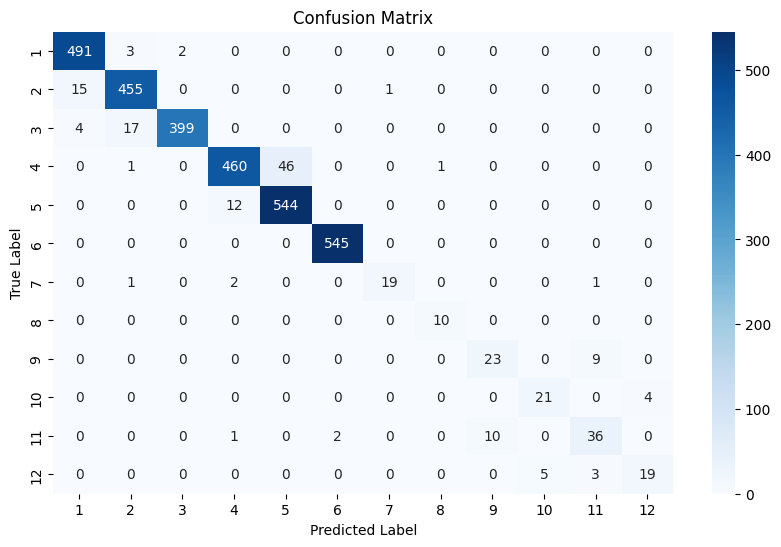

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# visualize
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

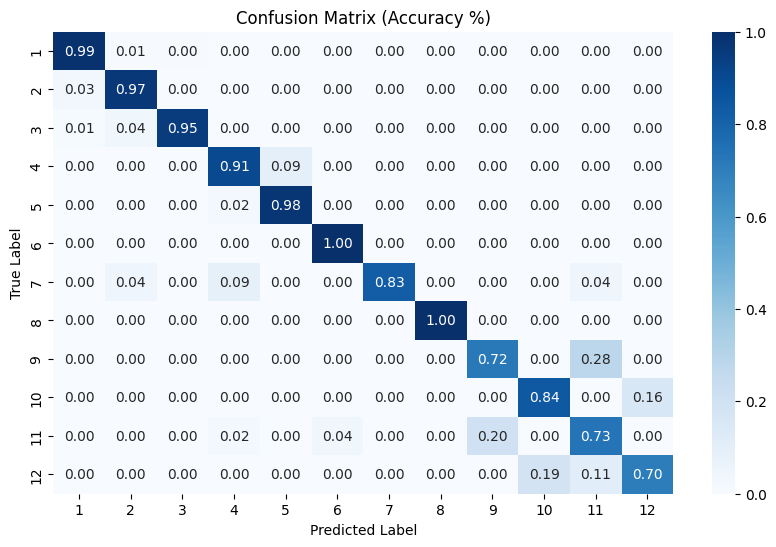

In [26]:
conf_matrix_normalized = conf_matrix.astype(np.float32) / conf_matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=range(1, 13), yticklabels=range(1, 13))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Accuracy %)")
plt.show()

The confusion matrices showed strong diagonal concentration, indicating that most predictions were correct. However, several consistent misclassifications occurred:

- `LIE_TO_STAND` vs. `LIE_TO_SIT`
- `SIT_TO_LIE` vs. `STAND_TO_LIE`
- `STAND_TO_LIE` vs. `SIT_TO_LIE`

These transition activities involve subtle movement differences that may produce highly similar sensor patterns, especially within the same body region (e.g., torso rotations, short vertical shifts). Additionally, the number of samples for these classes is small, which may further hinder the classifier’s ability to learn nuanced distinctions.

#### Multi-Class ROC Curves

- High area under the curve (AUC > 0.90) for major classes
- Reasonable AUC for minority classes, though with more variance

The ROC curves demonstrate that the model performs exceptionally well across all classes. Most classes achieve an AUC of 1.00, indicating near-perfect separability between positive and negative samples. Even the classes with the lowest scores achieve an AUC of 0.99, which is still highly satisfactory.

This result confirms that the model is capable of distinguishing between different activity classes with high confidence, including those that are typically difficult to classify, such as transitional movements.

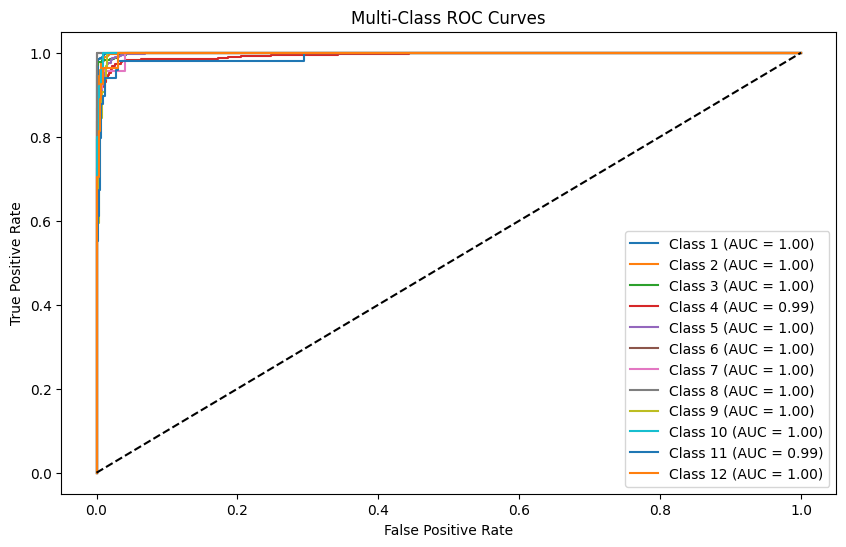

In [27]:
from sklearn.preprocessing import label_binarize

# One-vs-Rest
y_test_bin = label_binarize(y_test, classes=np.arange(1, 13))  # 12 One-vs-All
n_classes = y_test_bin.shape[1]

# compute ROC-AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i+1} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curves")
plt.legend(loc="lower right")
plt.show()

#### Precision-Recall Curves

While the ROC curves are impressive, the PR curves offer additional insights, particularly for imbalanced classes. For frequent activities such as `WALKING`, `SITTING`, and `STANDING` (Classes 1-6), the PR curves are smooth and concentrated in the top-right corner, suggesting high precision and recall.

However, for transitional activities (Classes 7-12), the PR curves show noticeable fluctuations and lower precision. For example, Class 12 (`LIE_TO_STAND`) and Class 10 (`LIE_TO_SIT`) show steep drops in precision at low recall values. This indicates that although the model retrieves many true positive samples for these classes (high recall), it also misclassifies many other classes as these transitions (low precision). The erratic and jagged PR curves is typical in imbalanced classification tasks where the number of samples for certain classes (transitional postures, Classes 7-12) is much smaller compared to others.

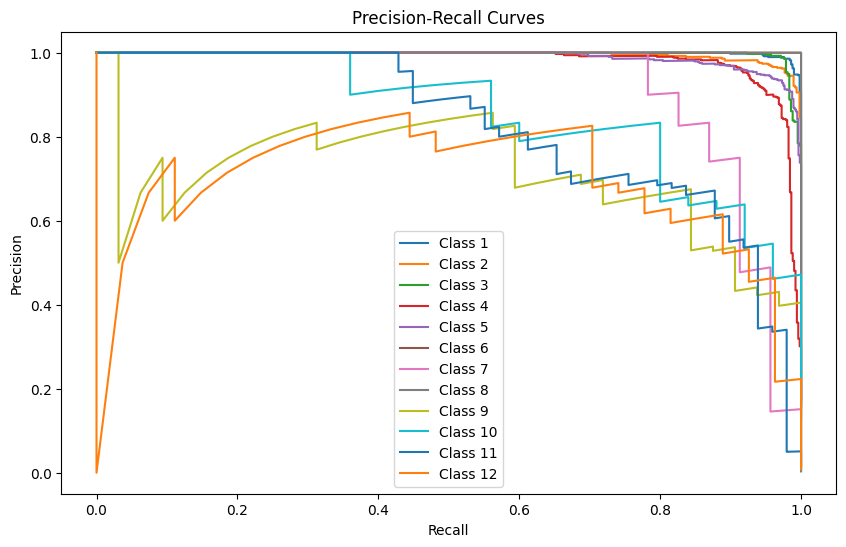

In [28]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"Class {i+1}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

Based on the PR curves and previous confusion matrix analysis, we suspect that several transitional classes are often confused with each other due to their symmetrical motion patterns or similar sensor signatures. Some notable examples include:

| Class | Likely Confused With | Reason |
|-------|----------------------|--------|
| `LIE_TO_STAND` | `LIE_TO_SIT`, `SIT_TO_STAND` | Similar vertical movement, hard to distinguish transitions |
| `SIT_TO_LIE` | `LIE_TO_SIT` | Reversed motion with similar acceleration profile |
| `STAND_TO_LIE` | `SIT_TO_LIE` | Same end posture (lying), initial state not clearly distinguishable |
| `STAND_TO_SIT` / `SIT_TO_STAND` | Each other | Symmetrical movements in opposite directions |

Despite some challenges in transition classes, the model still achieves competitive performance for these categories, with AUCs nearing 0.99. This suggests that the model has successfully learned meaningful representations, but precision drops due to the class imbalance and subtle signal differences between similar actions.

### Future Improvements
To address the limitations observed in transition activity classification, several improvements could be made:
1. Data Augmentation: Oversample underrepresented classes to balance the training dataset.
2. Contextual Features: Incorporate a sliding window approach or utilize context from adjacent time steps to provide richer input signals for classification.
3. Cost-Sensitive Training: Introduce class-specific weighting in the loss function to penalize misclassification of rare transition classes more heavily.
4. Post-Processing Smoothing: Apply sequential filtering (e.g., HMM or majority voting across windows) to reduce noisy or inconsistent predictions.


## Conlcusion
In this project, I implemented and systematically evaluated various SVM models—including linear, polynomial, and RBF kernels—for smartphone-based human activity recognition. I applied dimensionality reduction and addressed class imbalance using PCA and SMOTE respectively. Among the tested models, the RBF SVM with tuned hyperparameters (`C=23`, `gamma='scale'`) achieved the best overall performance, balancing accuracy and generalization to rare transition activities. Despite minor drawbacks from PCA and SMOTE, the final model demonstrates robust classification ability in a high-dimensional, multi-class setting.

### Reference

[1] Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), 273–297.  Available at: https://doi.org/10.1007/BF00994018.

[2] Hsu, C. W., Chang, C. C., & Lin, C. J. (2010). A practical guide to support vector classification. Available at: https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf.